In [1]:
import sys
from pathlib import Path

#sys.path.append(str(Path().resolve().parent))

In [2]:

import argparse
import time
import numpy as np
from sklearn.datasets import make_blobs

import hdbscan


from core_sg import CoreSGClusterer

# Building Dataset

In [3]:
n = 15000
d = 2
centers = 10
k = 30
seed = 42
atol = 1e-12
rtol = 1e-9

print(f"Generating synthetic dataset: n={n}, d={d}, centers={centers}, seed={seed}")
X, _ = make_blobs(
    n_samples=n,
    n_features=d,
    centers=centers,
    random_state=seed)

Generating synthetic dataset: n=15000, d=2, centers=10, seed=42


# Building CoreSG

In [4]:
%%time
# --- Build Core-SG (calculando pairwise dentro) ---
core_sg_clusterer = CoreSGClusterer(k_max=k, metric='euclidean',p=2,verbose=1,no_noise=False, match_reference_implementation=True)
core_sg_clusterer.fit(X, k=k)
core_sg_ = core_sg_clusterer.core_sg_

Core-SG build done in 31.73s
CPU times: user 26.1 s, sys: 8.08 s, total: 34.2 s
Wall time: 31.7 s


**Labels for k_max**

In [5]:
core_sg_.labels_k_max_

array([4, 1, 3, ..., 1, 1, 0], shape=(15000,))

# Extracting MSTs for different k values

k=30 -> 1.1682510375976562e-05 secs
REWEIGHT Core_SG = 28 done in 0.45s
KRUSKAL Core_SG = 28 done in 1.93s
Core-SG MST K = 28 (Kruskal) done in 2.39s
FOSC K = 28 done in 1.35s
k=28 -> 3.8676071166992188 secs
REWEIGHT Core_SG = 26 done in 0.53s
KRUSKAL Core_SG = 26 done in 1.65s
Core-SG MST K = 26 (Kruskal) done in 2.19s
FOSC K = 26 done in 1.13s
k=26 -> 3.444223165512085 secs
REWEIGHT Core_SG = 24 done in 0.39s
KRUSKAL Core_SG = 24 done in 1.52s
Core-SG MST K = 24 (Kruskal) done in 1.91s
FOSC K = 24 done in 0.91s
k=24 -> 2.9276251792907715 secs
REWEIGHT Core_SG = 22 done in 0.36s
KRUSKAL Core_SG = 22 done in 1.53s
Core-SG MST K = 22 (Kruskal) done in 1.90s
FOSC K = 22 done in 0.91s
k=22 -> 2.9075262546539307 secs
REWEIGHT Core_SG = 20 done in 0.37s
KRUSKAL Core_SG = 20 done in 1.51s
Core-SG MST K = 20 (Kruskal) done in 1.89s
FOSC K = 20 done in 1.01s
k=20 -> 2.9916157722473145 secs
REWEIGHT Core_SG = 18 done in 0.38s
KRUSKAL Core_SG = 18 done in 1.50s
Core-SG MST K = 18 (Kruskal) done 

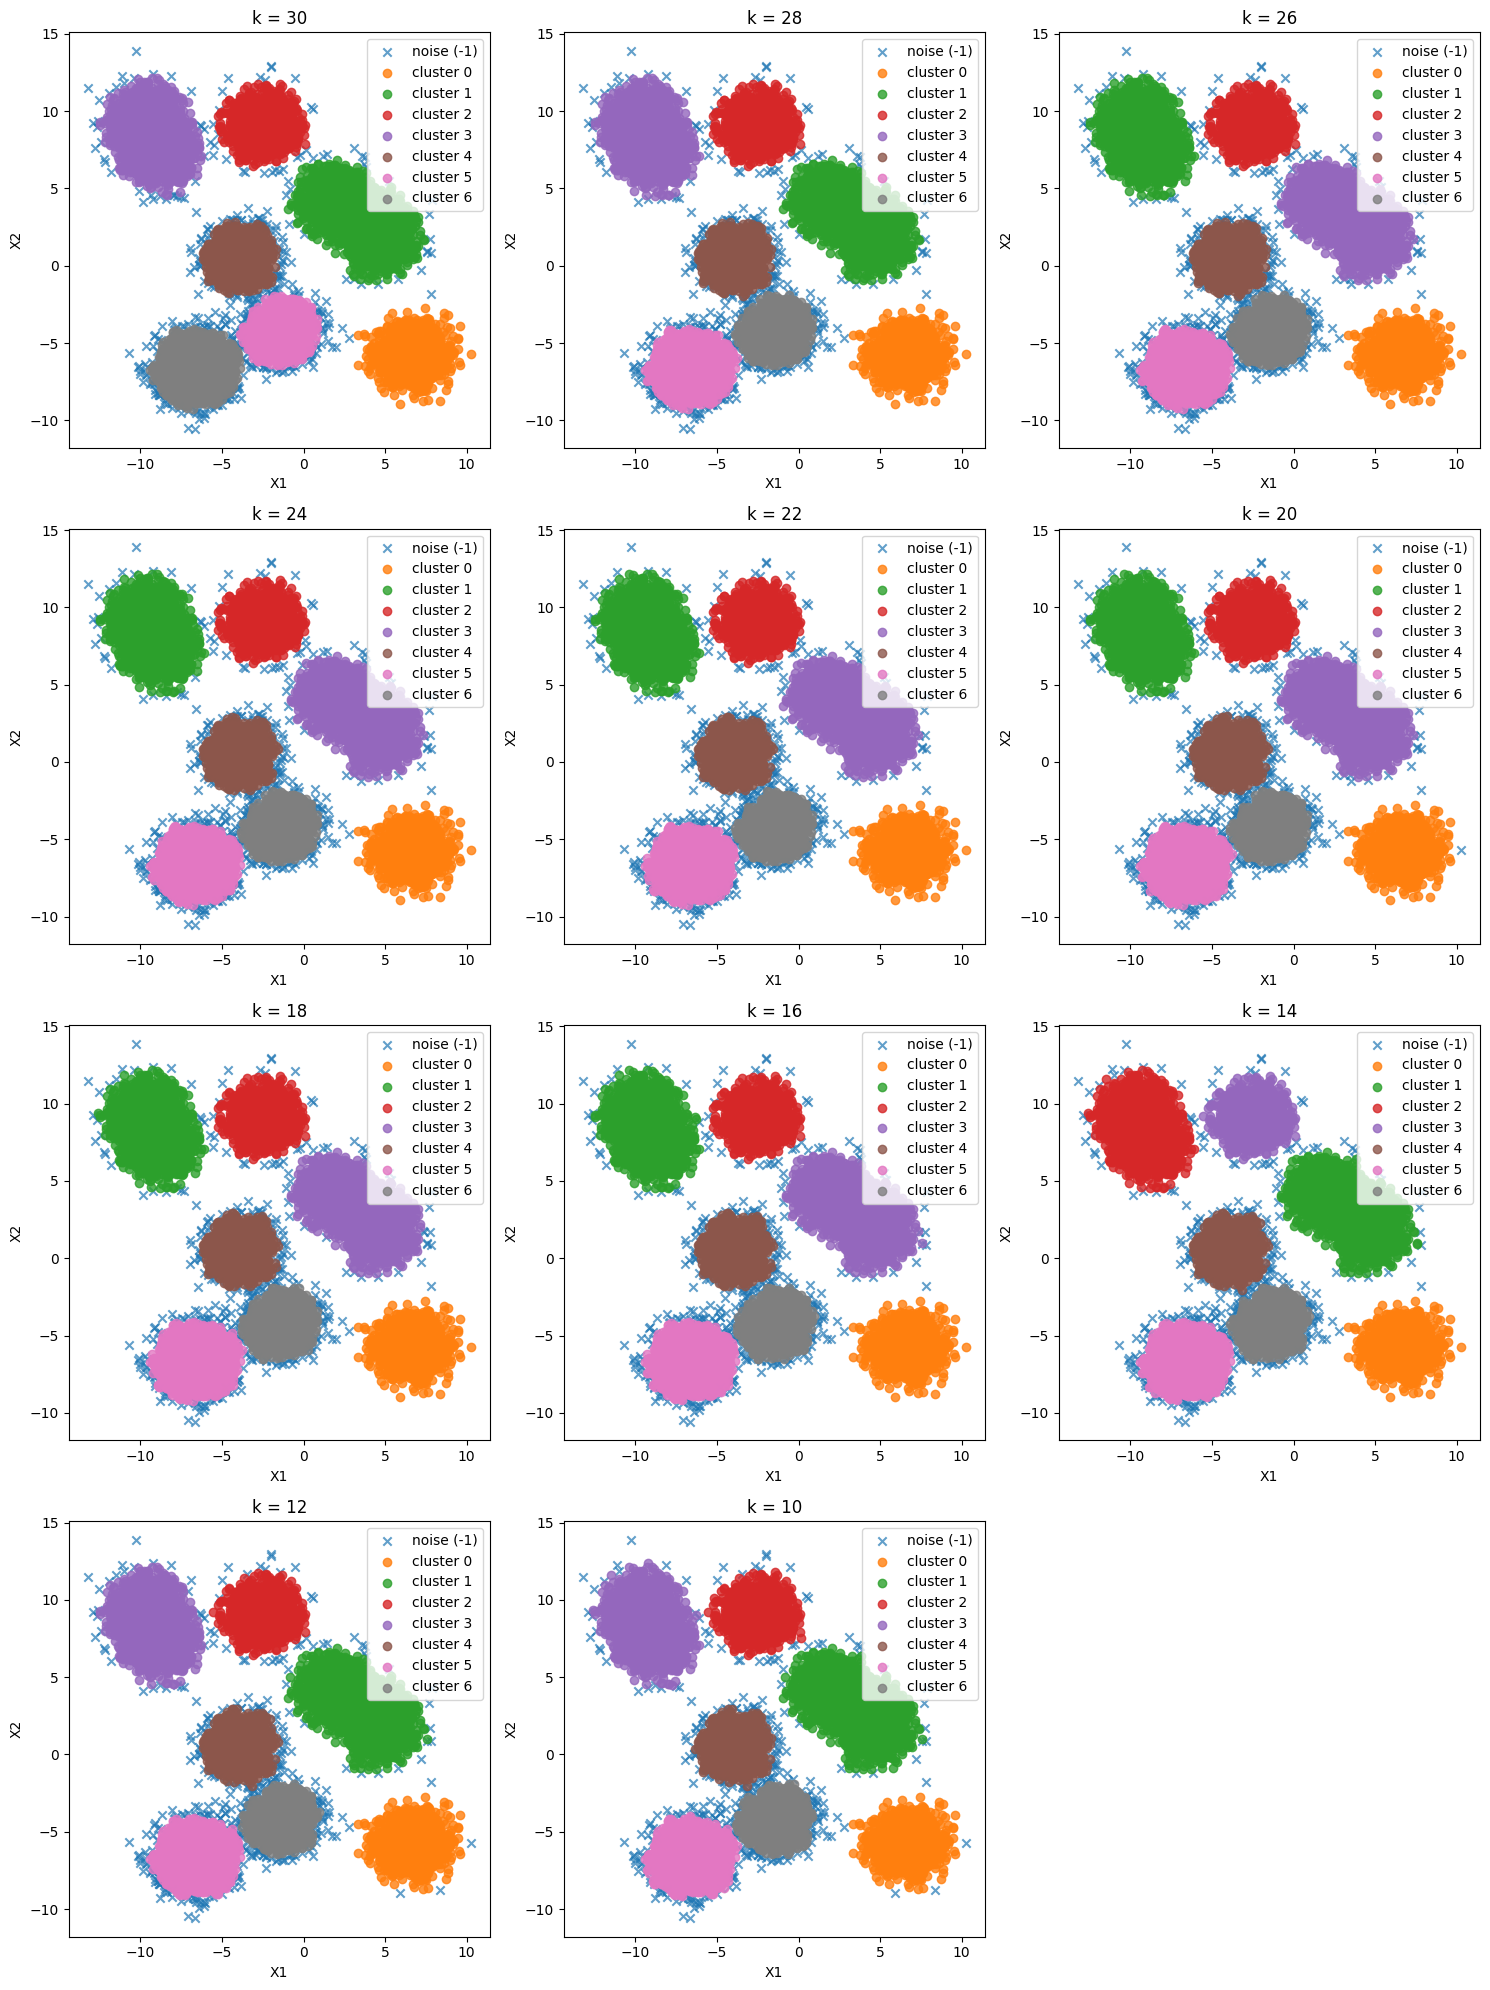

In [6]:
import math
import matplotlib.pyplot as plt
import numpy as np

results = []
from time import time
core_sg_.set_verbose(True)
for k_iter in range(k, 8, -2):
    t0 = time()
    core_sg_.extract_hierarchy_from_core_sg(k_iter)
    t1 = time()
    labels = core_sg_.labels_.copy()
    results.append((k_iter, labels))
    #print(f"k={k_iter} -> labels: {labels}")
    print(f"k={k_iter} -> {t1-t0} secs")

n_plots = len(results)
n_cols = min(3, n_plots)
n_rows = math.ceil(n_plots / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, (k_iter, labels) in zip(axes, results):
    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = labels == label

        if label == -1:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                label="noise (-1)",
                alpha=0.7,
                marker="x"
            )
        else:
            ax.scatter(
                X[mask, 0], X[mask, 1],
                label=f"cluster {label}",
                alpha=0.8
            )

    ax.set_title(f"k = {k_iter}")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.legend()

for ax in axes[n_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Getting Core-SG  MRD K_pts

In [7]:
core_sg_.get_core_sg_mutual_reachability_distance(k=15)

array([[3.7240e+03, 1.0518e+04, 7.3900e-02],
       [3.7240e+03, 1.0518e+04, 7.3900e-02],
       [2.0900e+02, 3.7240e+03, 7.4200e-02],
       ...,
       [2.0070e+03, 3.7540e+03, 2.6535e+00],
       [2.4720e+03, 3.7540e+03, 2.6755e+00],
       [2.0730e+03, 3.7540e+03, 2.6920e+00]], shape=(464999, 3))

# Getting MST, Single Linkage e Condensed Tree

In [8]:
core_sg_.extract_hierarchy_from_core_sg(20)
attributes_val = {'mst': core_sg_.minimum_spanning_tree_,
                'slt': core_sg_.single_linkage_tree_,
                'condensed': core_sg_.condensed_tree_,
}

REWEIGHT Core_SG = 20 done in 0.37s
KRUSKAL Core_SG = 20 done in 1.51s
Core-SG MST K = 20 (Kruskal) done in 1.88s
FOSC K = 20 done in 0.99s


**MST**

In [9]:
attributes_val['mst'].to_pandas()

,from,to,distance
0,209,10611,0.0883
1,209,3724,0.0894
2,209,10518,0.0902
3,209,11098,0.0934
4,209,3944,0.0946
...,...,...,...
14994,122,853,1.9002
14995,192,5069,1.9954
14996,1865,10858,2.1046
14997,629,14959,2.2320


**Single Linkage Tree**

In [10]:
attributes_val['slt'].to_pandas()

,parent,left_child,right_child,distance,size
0,15000,209.0,10611.0,0.0883,2.0
1,15001,15000.0,3724.0,0.0894,3.0
2,15002,15001.0,10518.0,0.0902,4.0
3,15003,15002.0,11098.0,0.0934,5.0
4,15004,15003.0,3944.0,0.0946,6.0
...,...,...,...,...,...
14994,29994,29993.0,853.0,1.9002,14996.0
14995,29995,29994.0,5069.0,1.9954,14997.0
14996,29996,29995.0,10858.0,2.1046,14998.0
14997,29997,29996.0,14959.0,2.2320,14999.0


**Condesed Tree**

In [11]:
attributes_val['condensed'].to_pandas()

,parent,child,lambda_val,child_size
0,15000,3754,0.404989,1
1,15000,14959,0.448029,1
2,15000,10858,0.475150,1
3,15000,5069,0.501153,1
4,15000,853,0.526260,1
...,...,...,...,...
15145,15150,11430,9.354537,1
15146,15150,7694,9.354537,1
15147,15150,3484,9.354537,1
15148,15150,11851,9.354537,1
